In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import re
from textblob import TextBlob
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import string
import pickle


## Importing Dataset

In [3]:
df = pd.read_csv('chat_dataset.csv')

In [4]:
df.head()

,text,label
0,Ex Wife Threatening SuicideRecently I left my ...,suicide
1,Am I weird I don't get affected by compliments...,normal
2,Finally 2020 is almost over... So I can never ...,normal
3,i need helpjust help me im crying so hard,suicide
4,"I’m so lostHello, my name is Adam (16) and I’v...",suicide


# Data Analysis and Preprocessing

In [5]:
df.shape

(304549, 2)

## Handling the Null Values

In [6]:
df.isnull().sum()

text         0
label    41177
dtype: int64

In [7]:
df=df.dropna()

- AS missing values are only 13% so, we cannot neglect them
- Handling them is necessary
- Dropping the null values (13% Null values) safe for NLP  

In [8]:
df.isnull().sum()

text     0
label    0
dtype: int64

## Handling the Duplicate Values

In [9]:
df.duplicated().sum()

np.int64(8)

In [10]:
df = df.drop_duplicates()

- As duplicated values aur only 8 so, dropping them is not a big deal

## Data distribution

In [11]:
df['label'].value_counts()

label
normal      123974
suicide     116037
bullying     19190
hate          4163
Name: count, dtype: int64

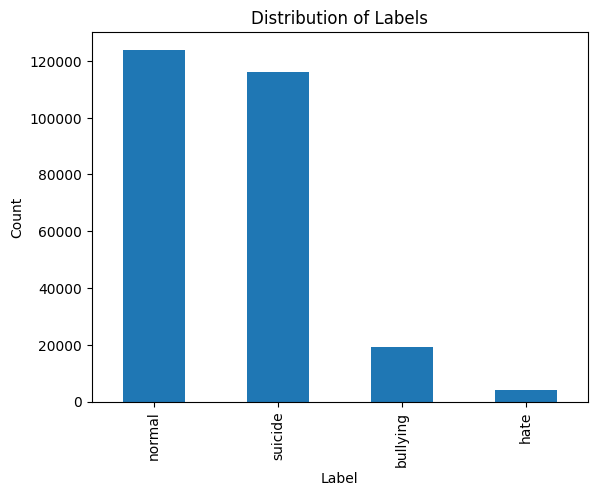

In [12]:
df['label'].value_counts().plot(kind='bar')
plt.xlabel('Label') 
plt.ylabel('Count')
plt.title('Distribution of Labels')
plt.show()

- Dataset is not balanced it can cause problems
- Model may learn normal and sucide classes correctly 
- weak learning of bullying is possible
- model cannot learn correctly hate class
- We have to handle imbalanced dataset

## Clean Text Function

In [13]:
def clean_text(text):
    try:
        text = str(text)
        

        # Converting to lowercase
        text = text.lower() 

        # Removing URLS
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

        # Removing HTML tags
        text = re.sub(r'<.*?>', '', text)

        # Removing Punctuation
        text = text.translate(str.maketrans('', '', string.punctuation))

        # Chat Words Treatment 
        text = chat_words_analysis(text)
        return text
    except: 
        return ""
    

    

    

    
    

    

### Function to handle Slang Words

In [14]:
chat_words = {
    
    "u": "you",
    "ur": "your",
    "r": "are",
    "btw": "by the way",
    "idk": "i do not know",
    "imo": "in my opinion",
    "imho": "in my humble opinion",
    "lol": "laughing out loud",
    "lmao": "laughing my ass off",
    "rofl": "rolling on floor laughing",
    "omg": "oh my god",
    "omw": "on my way",
    "brb": "be right back",
    "bbl": "be back later",
    "ttyl": "talk to you later",
    "gtg": "got to go",
    "gr8": "great",
    "b4": "before",
    "2day": "today",
    "2moro": "tomorrow",
    "luv": "love",
    "k": "okay",
    "kk": "okay",
    "okie": "okay",
    "pls": "please",
    "plz": "please",
    "thx": "thanks",
    "ty": "thank you",
    "np": "no problem",
    "smh": "shaking my head",
    "tbh": "to be honest",
    "fomo": "fear of missing out",
    "bae": "before anyone else",
    "lit": "amazing",
    "salty": "angry or bitter",
    "sus": "suspicious",
    "dm": "direct message",
    "rn": "right now",
    "af": "as f***",
    "ikr": "i know right",
    "yolo": "you only live once",
    "ftw": "for the win",
    "idc": "i do not care",
    "wyd": "what are you doing",
    "wya": "where you at",
    "hbu": "how about you",
    "afaik": "as far as i know",
    "tldr": "too long didn't read",

    "fr": "for real",
    "ngl": "not gonna lie",
    "fs": "for sure",
    "dead": "very funny / shocked",
    "no cap": "no lie",
    "cap": "lie",
    "lowkey": "slightly",
    "highkey": "obviously",
    "vibes": "feelings / mood",
    "mood": "relatable feeling",
    "slay": "doing great",
    "fire": "excellent",
    "mid": "average / bad",
    "hits different": "feels unique",

   
    "cuz": "because",
    "coz": "because",
    "bc": "because",
    "bcz": "because",
    "pls": "please",
    "plz": "please",
    "msg": "message",
    "txt": "text",
    "grl": "girl",
    "boi": "boy",

   
    "gg": "good game",
    "wp": "well played",
    "noob": "beginner",
    "afk": "away from keyboard",
    "ppl": "people",
    "ez": "easy",
    "nerf": "weaken",
    "buff": "strengthen",

    "i cant": "i cannot",
    "cant take it": "cannot handle situation",
    "done": "mentally exhausted",
    "broken": "emotionally hurt",
    "helpless": "feeling helpless",
}

def chat_words_analysis(text):
    new_text = []
    for w in text.split():
        if w in chat_words:
            new_text.append(chat_words[w])
        else:
            new_text.append(w)
    return ' '.join(new_text)

## Seperating Dependent and Independent Variables

In [15]:
x = df['text']
y = df['label']

## Encoding

In [16]:
le = LabelEncoder()
y = le.fit_transform(y)

## Saving the Encoder

In [17]:
with open("chatAnalysisEncoder.pkl", "wb") as f:
    pickle.dump(le, f)

## Train Test Splitting

In [18]:

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size =0.2)

## Creating Pipeline

In [19]:
pipeline = Pipeline([(
    "tfidf" ,TfidfVectorizer(
        preprocessor=clean_text,
        ngram_range=(1,2),
        max_features=10000,
        
    )),
    (
    "model",SVC(class_weight='balanced')
    )
])

## Model Training

In [ ]:
pipeline.fit(x_train,y_train)

## Model Prediction

In [93]:
y_pred = pipeline.predict(x_test)

## Model Evaluation

### Checking Accuracy

In [94]:
accuracy_score(y_test,y_pred)

0.9205665141533613

### Classification Report

In [95]:
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.91      0.88      0.89      3944\n           1       0.45      0.51      0.48       794\n           2       0.91      0.93      0.92     24759\n           3       0.95      0.93      0.94     23176\n\n    accuracy                           0.92     52673\n   macro avg       0.81      0.81      0.81     52673\nweighted avg       0.92      0.92      0.92     52673\n'

### Confusion Matrix

In [96]:
confusion_matrix(y_test,y_pred)

array([[ 3464,   136,   338,     6],
       [   89,   401,   298,     6],
       [  241,   331, 23033,  1154],
       [    8,    24,  1553, 21591]])

## Saving the model

In [100]:
with open("chatAnalysisModel.pkl", "wb") as f:
    pickle.dump(pipeline, f)

In [1]:
import sklearn
print(sklearn.__version__)

1.8.0
